In [ ]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import pydicom
from PIL import Image
from tqdm import tqdm
import timm
import pickle

DATA_PATH = "D:/ML/RSNA2024"

c:\Users\Manuel\anaconda3\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


## Data Processing

In [ ]:
df = pd.read_csv(os.path.join(DATA_PATH, "test_series_descriptions.csv"))
df.head(10)


,study_id,series_id,series_description
0,44036939,2828203845,Sagittal T1
1,44036939,3481971518,Axial T2
2,44036939,3844393089,Sagittal T2/STIR


In [ ]:
allStudyIds = df["study_id"].unique()
allStudyIds

array([44036939], dtype=int64)

In [ ]:
dfTrain = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
dfTrain = dfTrain.fillna("Normal/Mild")
dfTrain.set_index("study_id", inplace=True)

dfCoord = pd.read_csv(os.path.join(DATA_PATH, "train_label_coordinates.csv"))

allConditions = pd.unique(dfCoord["condition"])
allLevels = pd.unique(dfCoord["level"])
allLabels = np.array(dfTrain.columns)

labelMapping = {"Normal/Mild": 0, "Moderate":1, "Severe":2}

print(allConditions)
print(allLabels)

['Spinal Canal Stenosis' 'Right Neural Foraminal Narrowing'
 'Left Neural Foraminal Narrowing' 'Left Subarticular Stenosis'
 'Right Subarticular Stenosis']
['spinal_canal_stenosis_l1_l2' 'spinal_canal_stenosis_l2_l3'
 'spinal_canal_stenosis_l3_l4' 'spinal_canal_stenosis_l4_l5'
 'spinal_canal_stenosis_l5_s1' 'left_neural_foraminal_narrowing_l1_l2'
 'left_neural_foraminal_narrowing_l2_l3'
 'left_neural_foraminal_narrowing_l3_l4'
 'left_neural_foraminal_narrowing_l4_l5'
 'left_neural_foraminal_narrowing_l5_s1'
 'right_neural_foraminal_narrowing_l1_l2'
 'right_neural_foraminal_narrowing_l2_l3'
 'right_neural_foraminal_narrowing_l3_l4'
 'right_neural_foraminal_narrowing_l4_l5'
 'right_neural_foraminal_narrowing_l5_s1'
 'left_subarticular_stenosis_l1_l2' 'left_subarticular_stenosis_l2_l3'
 'left_subarticular_stenosis_l3_l4' 'left_subarticular_stenosis_l4_l5'
 'left_subarticular_stenosis_l5_s1' 'right_subarticular_stenosis_l1_l2'
 'right_subarticular_stenosis_l2_l3' 'right_subarticular_stenos

In [ ]:
allFiles = []

for root, dirs, files in os.walk(os.path.join(DATA_PATH, "test_images")):
    for f in files:
        if f.endswith(".dcm"):
            allFiles.append(os.path.join(root,f))

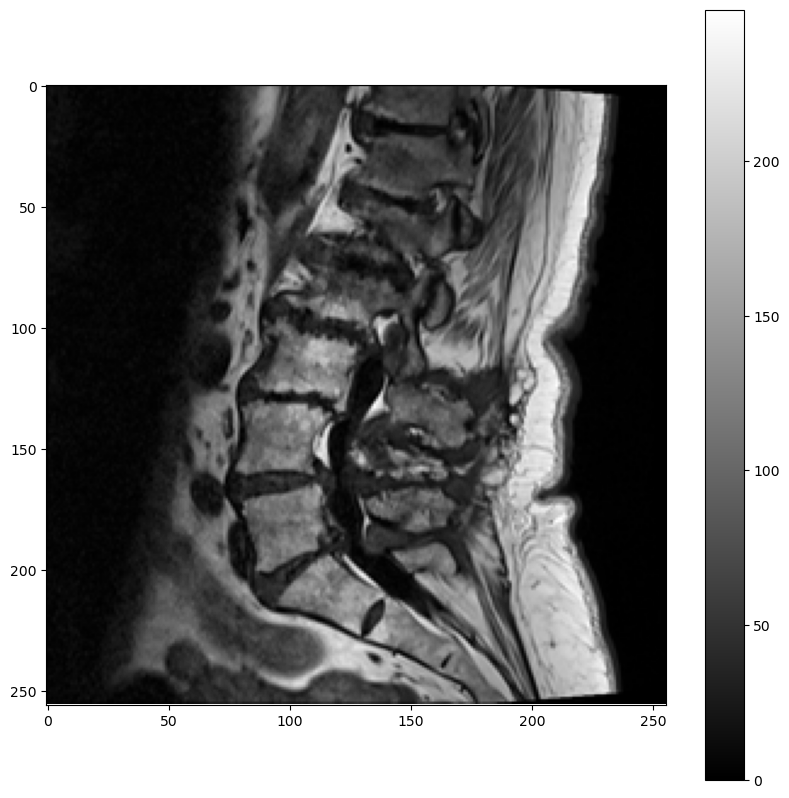

In [ ]:
IMG_SIZE = (256, 256)
eps=1e-12

def dicomToArray(path):
    dicom = pydicom.read_file(path)
    data = pydicom.pixel_data_handlers.util.apply_modality_lut(dicom.pixel_array, dicom)
    data = pydicom.pixel_data_handlers.util.apply_windowing(data, dicom)
    # data = dicom.pixel_array
    if dicom.PhotometricInterpretation == "MONOCHROME1":
        data = np.amax(data) - data
        
    w, h = data.shape[0], data.shape[1]

    #Center crop
    if w>h:
        diff = w-h
        data = data[diff//2:diff//2+h, :]
    if h>w:
        diff = h-w
        data = data[:, diff//2:diff//2+w]

    data = data - np.min(data)
    data = data * 1.0/(np.max(data)+eps)

    w, h = data.shape[0], data.shape[1]

    # resize
    if not (w == IMG_SIZE[0] and h == IMG_SIZE[1]):
        data = np.array(Image.fromarray((data * 255).astype(np.uint8), mode="L").resize(IMG_SIZE))

    return data


plt.figure(figsize=(10,10))
_ = plt.imshow(dicomToArray(os.path.join(DATA_PATH, "test_images/44036939/2828203845/15.dcm")), cmap="gray")
_ = plt.colorbar()



## Dataset

In [ ]:
allFiles[0]

'D:/ML/RSNA2024\\test_images\\44036939\\2828203845\\1.dcm'

In [ ]:
X=[]
description=[]
for i,filePath in enumerate(tqdm(allFiles)):
    isTma = False
    parts = filePath.split("\\")
    instance = int(parts[-1].replace(".dcm", ""))
    seriesId = int(parts[-2])
    studyId = int(parts[-3])
        
    im = dicomToArray(filePath)
    
    X.append(im)
    description.append({"seriesId": seriesId, "studyId": studyId})

print(len(X))
print(X[0].shape)

100%|██████████| 97/97 [00:01<00:00, 66.11it/s] 

97
(256, 256)


In [ ]:
from torchvision.transforms import v2

transforms = v2.Compose([
    v2.Grayscale(3),
    v2.Resize(IMG_SIZE),
    v2.ToDtype(torch.float32),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# list(zip()) because otherwise the zip function is a lazy generator itself
# --> The zip will end although the generator gets re-initialized
dataZipped = list(zip(X, description))


def generator():
    for im, descr in dataZipped:
        im = np.expand_dims(im,0)
        im = im.astype(np.float32)/255.0
        im = transforms(torch.Tensor(im))
        yield im, descr


tensor(-2.1179) tensor(2.1694)
torch.Size([3, 256, 256])
{'seriesId': 2828203845, 'studyId': 44036939}


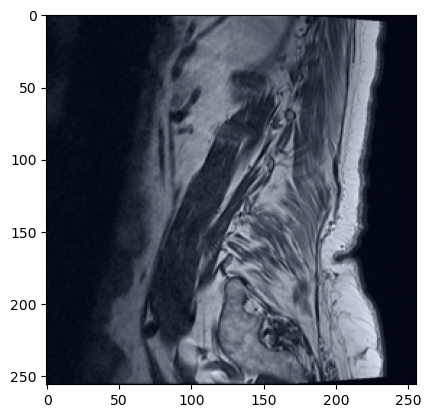

In [ ]:
g = generator()
testInstance = next(g)

plt.imshow((torch.moveaxis(testInstance[0], 0,-1)*0.225)+0.485)
print(torch.min(testInstance[0]), torch.max(testInstance[0]))
print(testInstance[0].shape)
print(testInstance[1])

In [ ]:
BATCH_SIZE = 32

class IterDataset(torch.utils.data.IterableDataset):
    def __init__(self, generator, length):
        self.generator = generator
        self.len = length

    def __iter__(self):
        return self.generator()
    
    def __len__(self):
        return self.len
    
dataset = IterDataset(generator, len(X))

dataLoader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
for XData in dataLoader:
# for X, targets, targetsE,targetsK,targetsL,targetsS, patIds in trainLoader:
    print(f"Shape of X: {XData[0].shape} {XData[0].dtype}")
    print("Max and Min: ", torch.max(XData[0]), torch.min(XData[0]))
    print(XData[1])
    break

Shape of X: torch.Size([32, 3, 256, 256]) torch.float32
Max and Min:  tensor(2.6400) tensor(-2.1179)
{'seriesId': tensor([2828203845, 2828203845, 2828203845, 2828203845, 2828203845, 2828203845,
        2828203845, 2828203845, 2828203845, 2828203845, 2828203845, 2828203845,
        2828203845, 2828203845, 2828203845, 2828203845, 2828203845, 2828203845,
        2828203845, 2828203845, 2828203845, 2828203845, 2828203845, 2828203845,
        2828203845, 3481971518, 3481971518, 3481971518, 3481971518, 3481971518,
        3481971518, 3481971518]), 'studyId': tensor([44036939, 44036939, 44036939, 44036939, 44036939, 44036939, 44036939,
        44036939, 44036939, 44036939, 44036939, 44036939, 44036939, 44036939,
        44036939, 44036939, 44036939, 44036939, 44036939, 44036939, 44036939,
        44036939, 44036939, 44036939, 44036939, 44036939, 44036939, 44036939,
        44036939, 44036939, 44036939, 44036939])}


## Model

In [ ]:
import torchinfo

# model = timm.create_model('edgenext_base', pretrained=True, num_classes=len(allLabels)*len(labelMapping))
# model.name = f"edgenext_base_{IMG_SIZE[0]}"

# model = timm.create_model('resnet34d', pretrained=True, num_classes=len(enc.classes_))
# model.name = "resnet34d_384_wang"

# model = timm.create_model('rexnet_150', pretrained=True, num_classes=len(enc.classes_))
# model.name = "RexNet150"

class EdgeNext(torch.nn.Module):
    def __init__(self):
        super(EdgeNext, self).__init__()
        self.name="PathClassifierEdgeNext"

        self.basemodel = timm.create_model('edgenext_base', pretrained=True, num_classes=len(allLabels)*len(labelMapping))
        # self.basemodel = timm.create_model('edgenext_base', pretrained=True, num_classes=0)
        self.flatten = torch.nn.Flatten()
        self.linear2 = torch.nn.Linear(37376, len(allLabels)*len(labelMapping))
        # self.softmax = torch.nn.Softmax(dim=1)

    def forward(self, x):
        x = self.basemodel(x)
        # x = self.basemodel.forward_features(x)
        # x = self.flatten(x)
        # x = self.linear2(x)
        x = torch.reshape(x, (x.shape[0], len(labelMapping), len(allLabels)))
        # x = self.softmax(x)
        return x

model = EdgeNext()

from torchview import draw_graph

model_graph = draw_graph(model, input_size=(BATCH_SIZE,3,IMG_SIZE[0],IMG_SIZE[1]), expand_nested=True)
model = model.to(device)
torchinfo.summary(model, input_size=[BATCH_SIZE,3,IMG_SIZE[0],IMG_SIZE[1]])

Layer (type:depth-idx)                                            Output Shape              Param #
EdgeNext                                                          [32, 3, 25]               2,803,275
├─EdgeNeXt: 1-1                                                   [32, 75]                  --
│    └─Sequential: 2-1                                            [32, 80, 64, 64]          --
│    │    └─Conv2d: 3-1                                           [32, 80, 64, 64]          3,920
│    │    └─LayerNorm2d: 3-2                                      [32, 80, 64, 64]          160
│    └─Sequential: 2-2                                            [32, 584, 8, 8]           --
│    │    └─EdgeNeXtStage: 3-3                                    [32, 80, 64, 64]          157,920
│    │    └─EdgeNeXtStage: 3-4                                    [32, 160, 32, 32]         792,808
│    │    └─EdgeNeXtStage: 3-5                                    [32, 288, 16, 16]         6,628,552
│    │    └─EdgeN

In [ ]:

checkpoint = torch.load(os.path.join("./", "PathClassifierEdgeNext_F1_0.968_CrossEntropy_0.049_epoch_15.pt"), map_location=device)
print(model.load_state_dict(checkpoint['model_state_dict']))
model = model.to(device)


<All keys matched successfully>


In [25]:
results = {}

@torch.no_grad()
def validate(dataloader, model):
    model.eval()
    with torch.no_grad():
        for X, descr in dataloader:
            X = X.to(device)
            pred = model(X)
            for idx, studyId in enumerate(descr["studyId"]):
                if studyId.item() in results.keys():
                    results[studyId.item()].append(pred[idx].detach().cpu().numpy())
                else:
                    results[studyId.item()] = [pred[idx].detach().cpu().numpy()]
                # results[studyId.item()] = pred[idx]


validate(dataLoader, model)
 

print("Done!")
# print(results)

Done!


In [44]:
test = np.array(results[44036939])[:,:,2]
np.array(results[44036939]).shape

(97, 3, 25)

In [76]:
from scipy.special import softmax

entries = []

for studyId in results.keys():
    for condIdx, cond in enumerate(allLabels):
        instance = np.array(results[studyId])[:,:,condIdx]
        maxIndices = np.argmax(instance, axis=1)
        maxIndicesMild = np.where(maxIndices==0)
        maxIndicesModerate = np.where(maxIndices==1)
        maxIndicesSevere = np.where(maxIndices==2)
        meanProbSevere=[0,0,0]
        meanProbModerate=[0,0,0]
        meanProbMild=[0,0,0]
        if maxIndicesSevere[0].shape[0]>1:
            probs= softmax(instance[np.where(maxIndices==2)], axis=1)
            meanProbSevere = np.mean(probs, axis=0)
            print(f"{cond} severe: {meanProbSevere}")
        if maxIndicesModerate[0].shape[0]>1:
            probs= softmax(instance[np.where(maxIndices==1)], axis=1)
            meanProbModerate = np.mean(probs, axis=0)
            print(f"{cond} moderate: {meanProbModerate}")
        if maxIndicesMild[0].shape[0]>1:
            probs= softmax(instance[np.where(maxIndices==0)], axis=1)
            meanProbMild = np.mean(probs, axis=0)
            print(f"{cond} mild: {meanProbMild}")

        if meanProbSevere[2] > 0.5 and meanProbSevere[2] > meanProbModerate[1]:
            finalProb = meanProbSevere
        elif meanProbModerate[1] > 0.5 and meanProbModerate[1] > meanProbSevere[2]:
            finalProb = meanProbModerate
        elif meanProbMild[0] > 0.5:
            finalProb = meanProbMild
        else:
            finalProb = [0.34,0.33,0.33]

        entries.append([f"{studyId}_{cond}", *finalProb])
        

spinal_canal_stenosis_l1_l2 mild: [0.90961534 0.07128654 0.01909806]
spinal_canal_stenosis_l2_l3 severe: [0.1878586  0.23287371 0.5792676 ]
spinal_canal_stenosis_l2_l3 moderate: [0.30649036 0.5724596  0.12105003]
spinal_canal_stenosis_l2_l3 mild: [0.74661505 0.16561697 0.08776809]
spinal_canal_stenosis_l3_l4 moderate: [0.01272977 0.9600929  0.02717737]
spinal_canal_stenosis_l3_l4 mild: [0.65464    0.21050352 0.13485646]
spinal_canal_stenosis_l4_l5 severe: [0.27633634 0.04106981 0.6825937 ]
spinal_canal_stenosis_l4_l5 mild: [0.74304    0.09937833 0.15758166]
spinal_canal_stenosis_l5_s1 mild: [0.9727266  0.01774812 0.00952536]
left_neural_foraminal_narrowing_l1_l2 moderate: [0.20977624 0.78721535 0.00300837]
left_neural_foraminal_narrowing_l1_l2 mild: [0.86090374 0.13785388 0.00124241]
left_neural_foraminal_narrowing_l2_l3 severe: [0.3392682  0.17563713 0.4850947 ]
left_neural_foraminal_narrowing_l2_l3 moderate: [0.07711852 0.8616989  0.06118255]
left_neural_foraminal_narrowing_l2_l3 mil

In [79]:
dfSubmission = pd.DataFrame(entries, columns=["row_id","normal_mild","moderate","severe"])
dfSubmission.head(10)


,row_id,normal_mild,moderate,severe
0,44036939_spinal_canal_stenosis_l1_l2,0.909615,0.071287,0.019098
1,44036939_spinal_canal_stenosis_l2_l3,0.187859,0.232874,0.579268
2,44036939_spinal_canal_stenosis_l3_l4,0.012730,0.960093,0.027177
3,44036939_spinal_canal_stenosis_l4_l5,0.276336,0.041070,0.682594
4,44036939_spinal_canal_stenosis_l5_s1,0.972727,0.017748,0.009525
5,44036939_left_neural_foraminal_narrowing_l1_l2,0.209776,0.787215,0.003008
6,44036939_left_neural_foraminal_narrowing_l2_l3,0.077119,0.861699,0.061183
7,44036939_left_neural_foraminal_narrowing_l3_l4,0.121760,0.805807,0.072433
8,44036939_left_neural_foraminal_narrowing_l4_l5,0.064809,0.908553,0.026638
9,44036939_left_neural_foraminal_narrowing_l5_s1,0.083981,0.049374,0.866644


In [80]:
dfSubmission.to_csv("submission.csv", index=False)